In [1]:
# 데이터 전처리를 위한 파이썬 라이브러리
import pandas as pd

air = pd.read_csv('../da_data/ozone.csv')
air.head()

,Ozone,Solar.R,Wind,Temp,Date
0,41,190.0,7.4,67,1973-05-01
1,36,118.0,8.0,72,1973-05-02
2,12,149.0,12.6,74,1973-05-03
3,18,313.0,11.5,62,1973-05-04
4,19,NaN,14.3,56,1973-05-05


<Axes: xlabel='Temp', ylabel='Ozone'>

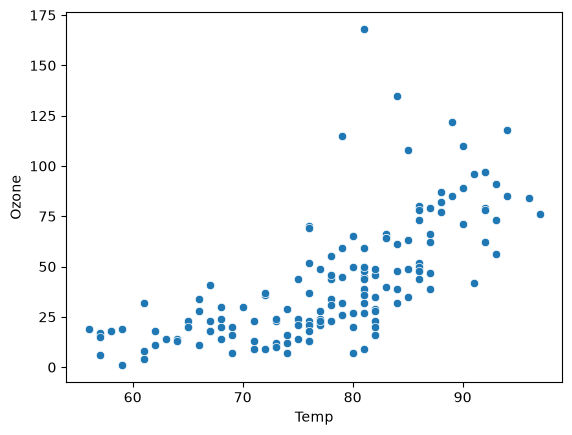

In [3]:
# matplotlib를 기반으로 만든 파이썬 시각화 라이브러리
import seaborn as sns

sns.scatterplot(x='Temp', y='Ozone', data=air)

<Axes: xlabel='Wind', ylabel='Ozone'>

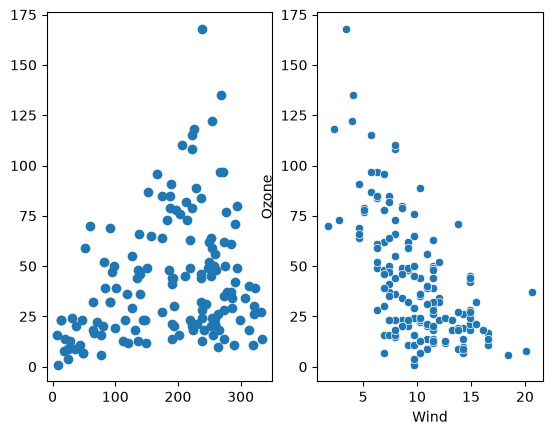

In [5]:
# 파이썬 시각화 라이브러리
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
plt.scatter('Solar.R', 'Ozone', data=air)
plt.subplot(1, 2, 2)
sns.scatterplot(x='Wind', y='Ozone', data=air)

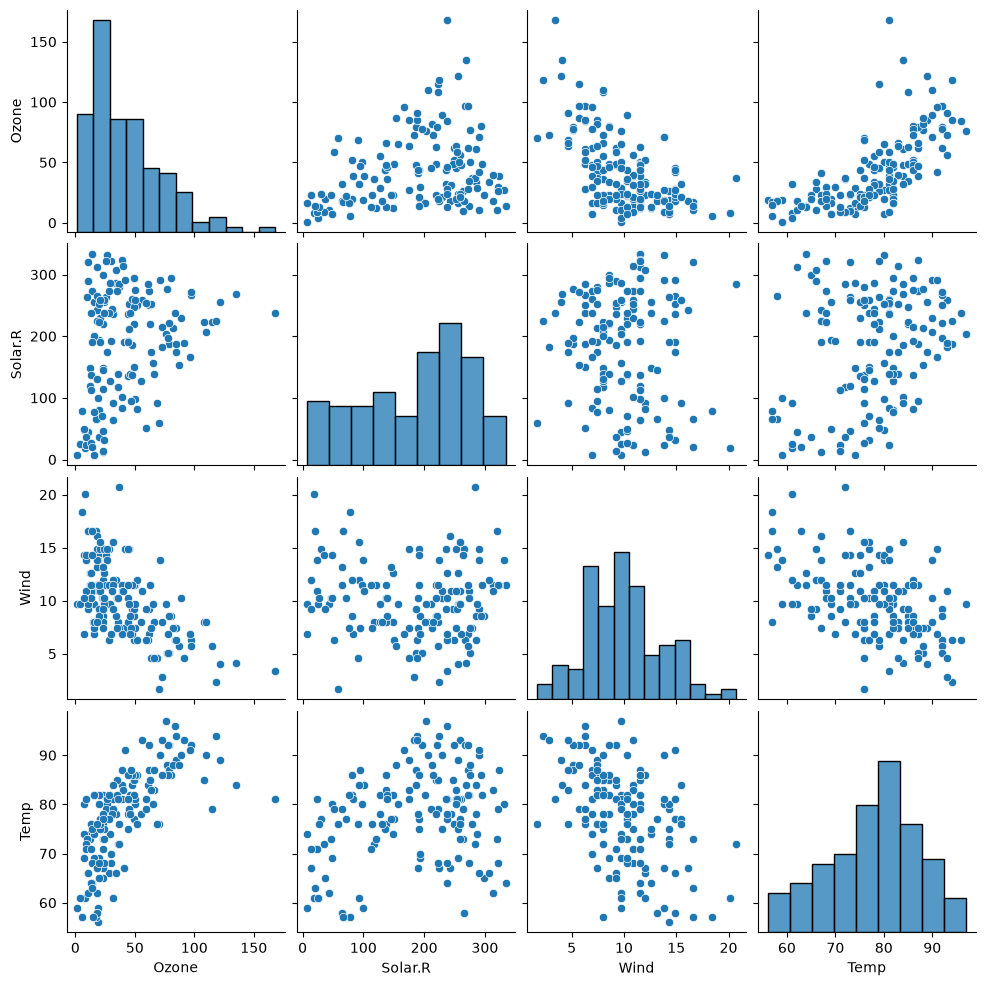

In [6]:
sns.pairplot(air)

<Axes: xlabel='Ozone', ylabel='Ozone'>

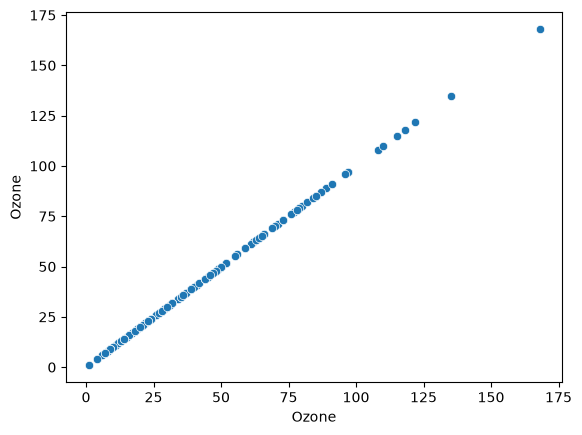

In [7]:
# 독립변수와 종속변수가 같은 경우, 항상 y=x인 기울기가 1인 직선이 그려지게 됨.
sns.scatterplot(x='Ozone', y='Ozone', data=air)

In [9]:
corr = air.corr(numeric_only=True)
corr

,Ozone,Solar.R,Wind,Temp
Ozone,1.000000,0.280068,-0.605478,0.683372
Solar.R,0.280068,1.000000,-0.056792,0.275840
Wind,-0.605478,-0.056792,1.000000,-0.457988
Temp,0.683372,0.275840,-0.457988,1.000000


<Axes: >

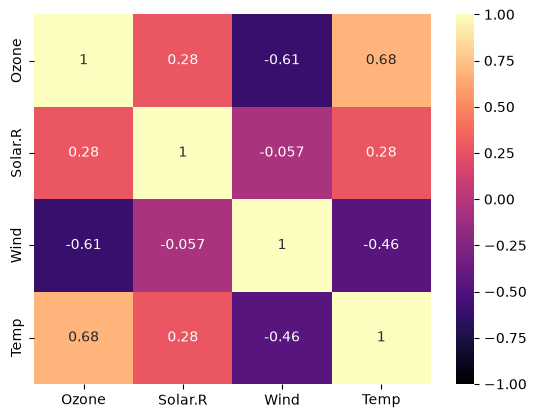

In [18]:
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, cmap='magma')

In [22]:
titanic = sns.load_dataset('titanic')

<Axes: xlabel='class', ylabel='sibsp'>

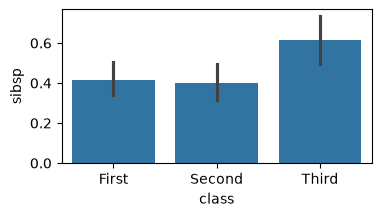

In [24]:
# 독립변수x : class
# 종속변수y : fare
plt.figure(figsize = (4, 2))
sns.barplot(x='class', y='sibsp', data = titanic)

<Axes: xlabel='sex', ylabel='age'>

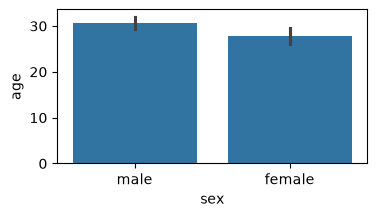

In [25]:
plt.figure(figsize = (4, 2))
sns.barplot(x = 'sex', y = 'age', data = titanic)

# 머신러닝(Machine Learning, ML)

In [26]:
import sklearn

In [27]:
print(pd.__version__, sklearn.__version__)

3.0.5 1.9.0


In [28]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [29]:
import pandas as pd

iris = load_iris()
iris_data = iris.data
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [34]:
iris_data = iris['data']
pd.DataFrame(data = iris_data, columns = iris['feature_names'])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [37]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size = 0.2, random_state = 11)
print(X_train[0])

[5.1 3.5 1.4 0.2]


In [ ]:
# 전체 데이터를 8:2 비율로 무작위로 섞어 2개의 데이터셋으로 쪼갬.
# 데이터 프레임을 두 개로 만들어
# 첫 번째 데이터 프레임을 iris_train에,
# 두 번째 데이터 프레임을 iris_test에 저장
iris_train, iris_test = train_test_split(iris_df, test_size = 0.2, random_state=11)

In [43]:
print(iris_train.shape)
iris_train.head()

(120, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
120,6.9,3.2,5.7,2.3,2
122,7.7,2.8,6.7,2.0,2
49,5.0,3.3,1.4,0.2,0
29,4.7,3.2,1.6,0.2,0


In [45]:
# 학습
dt_clf = DecisionTreeClassifier(random_state = 11)
dt_clf.fit(X_train, y_train)

# 예측
pred = dt_clf.predict(X_test)

# 평가
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, pred)

# 예측 정확도 출력
print(f'예측 정확도: {round(acc, 4)}')

예측 정확도: 0.9333


In [ ]:
iris_x = pd.DataFrame(iris_data, columns = iris.feature_names)
iris_y = pd.Series(iris.target)

In [ ]:
# 학습용 데이터, 테스트용 데이터 자르기
iris_train, iris_test = train_test_split(iris_df, test_size=0.2, random_state=11)

# 마지막 한개 컬럼을 뺀 모든 컬럼 선택
X_train = iris_train.iloc[:, :-1]
# iris_train.drop('label', axis=1)와 같음

# 라벨 컬럼만 (마지막 컬럼)
y_train = iris_train['label']

In [46]:
y = iris_df['label']
X = iris_df.drop('label', axis = 1)
train_test_split(X, y, test_size = 0.2, random_state=11)

[     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 120                6.9               3.2                5.7               2.3
 122                7.7               2.8                6.7               2.0
 49                 5.0               3.3                1.4               0.2
 29                 4.7               3.2                1.6               0.2
 ..                 ...               ...                ...               ...
 76                 6.8               2.8                4.8               1.4
 13                 4.3               3.0                1.1               0.1
 81                 5.5               2.4                3.7               1.0
 91                 6.1               3.0                4.6               1.4
 80                 5.5               2.4                3.8               1.1
 
 [120 rows x 4 columns],
      sepal length (cm)  

In [48]:
# 학습 데이터와 테스트 데이터는 8:2로 나누는 것이 보통
# 학습용 데이터는 최대한 많은 것이 보통 좋음.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print('학습 데이터의 수:', len(X_train))
print('테스트 데이터의 수:', len(X_test))

학습 데이터의 수: 120
테스트 데이터의 수: 30


In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()

# 독립변수들
features = iris.data

# 종속변수
label = iris.target

# Estimator root 클래스의 DecisionTreeClassifier 클래스를 사용하여
# 새로운 모델 생성
dt_clf = DecisionTreeClassifier(random_state = 156)

# K-Fold Cross Validation용 객체 생성
# n_splits = 교차 학습 횟수
# 데이터를 5개의 집단으로 나누기
kfold = KFold(n_splits = 5)

# 검증한 정확도들이 저장되는 배열
cv_accuracy = []

# 교차 검증 횟수
n_iter = 0

# 각 독립변수 배열들에 대해서
for train_index, test_index in kfold.split(features):
    
    # X_train, X_test, y_train, y_test 지정
    # features가 데이터프레임이라면
    # X_train = features.iloc[train_index] 
    X_train = features[train_index] 
    # X_test = features.iloc[test_index]
    X_test = features[test_index]
    # y_train = label.iloc[train_index]
    y_train = label[train_index] 
    # y_test = label.iloc[test_index]
    y_test = label[test_index]
    
    # 데이터 학습
    dt_clf.fit(X_train, y_train)
    
    # 학습된 모델에 테스트 값을 넣어 예측값 출력
    pred = dt_clf.predict(X_test)
    
    # 교차 검증 반복 횟수 추가
    n_iter += 1

    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('#',n_iter)
    print('교차 검증 정확도 :',accuracy)
    print('학습데이터 크기 :',train_size)
    print('검증데이터 크기 :',test_size)
    print('검증 인덱스 :',test_index)
    cv_accuracy.append(accuracy)
    print()

print('평균 검증 정확도 :', np.mean(cv_accuracy)) 

# 1
교차 검증 정확도 : 1.0
학습데이터 크기 : 120
검증데이터 크기 : 30
검증 인덱스 : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

# 2
교차 검증 정확도 : 0.9667
학습데이터 크기 : 120
검증데이터 크기 : 30
검증 인덱스 : [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

# 3
교차 검증 정확도 : 0.8667
학습데이터 크기 : 120
검증데이터 크기 : 30
검증 인덱스 : [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

# 4
교차 검증 정확도 : 0.9333
학습데이터 크기 : 120
검증데이터 크기 : 30
검증 인덱스 : [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

# 5
교차 검증 정확도 : 0.7333
학습데이터 크기 : 120
검증데이터 크기 : 30
검증 인덱스 : [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

평균 검증 정확도 : 0.9


In [55]:
# 딥러닝에서는 모델에 이전 데이터 위에 
# 새로운 데이터로 추가학습을 시킬 수 있지만,
# 머신러닝(Estimator)에서는 추가학습을 시킬 수 없다.


dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
dt_clf.fit(X_train2, y_train2)

NameError: name 'X_train2' is not defined

In [57]:
from sklearn.model_selection import cross_val_score, 

iris_data = load_iris()
df_clf = DecisionTreeClassifier(random_state = 156)

# 독립변수 X
data = iris_data.data

# 종속변수 Y
label = iris_data.target

# cross_val_score() : 
# 교차 검증을 자동으로 수행하고, 
# 각 폴드의 평가 점수를 반환해 주는 함수

scores = cross_val_score(dt_clf, data, label, scoring='accuracy', cv=5)
print('교차 검증별 정확도: ', np.round(scores, 4))
print('평균 검증 정확도: ', np.round(np.mean(scores), 4))

교차 검증별 정확도:  [0.9667 0.9667 0.9    1.     1.    ]
평균 검증 정확도:  0.9667


In [24]:
# GridSearchCV 불러오기 (model_selection 소속)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 붓꽃 데이터 불러오기
iris = load_iris()

# 학습용 데이터(독립, 종속), 검증용 데이터(독립, 종속) 설정
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,
                                                    test_size=0.2, random_state=121)

# Estimator 클래스의 DecisionTreeClassifier() 도구 가져오기
dtree = DecisionTreeClassifier()

# 하이퍼파라미터 지정 (max_depth와 min_samples_split)
# max_depth : 의사결정나무의 정지규칙1 (최대 깊이)
# min_samples_split : 의사결정나무의 정지규칙2 (노드를 분할하기 위해 필요한 최소 샘플(데이터) 개수)
parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}

# GridSearchCV(estimator, param_grid, cv, scoring, n_jobs)
# estimator : 튜닝할 모델 객체
# param_grid : 탐색할 하이퍼파라미터와 후보 값들을 담은 딕셔너리 또는 리스트
# cv : 교차검증 폴드 수 (기본값 5: '학습용8:검증용2로 가장 예쁨')
# scoring : 평가 기준('accuracy', 'f1', 'r2'등)
# n_jobs : 모든 CPU 코어 사용 여부 (-1이면 전부 사용)
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

grid_dtree.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_split': [2, 3]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed d

In [11]:
import pandas as pd
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score',
'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [14]:
print(f'GridSearchCV 최적 파라미터: {grid_dtree.best_params_}')
print(f'GridSearchCV 최고 정확도: {grid_dtree.best_score_:.4f}')

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.9750


In [17]:
grid_dtree.best_estimator_


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [18]:
DecisionTreeClassifier()

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [20]:
dt = DecisionTreeClassifier()
dt.predict(X_test)

NotFittedError: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [23]:
from sklearn.metrics import accuracy_score

max_depths = [ 6, 8 ,10, 12, 16 ,20, 24]

for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split=16, random_state=156)
    dt_clf.fit(X_train , y_train)

    pred = dt_clf.predict(X_test)
    accuracy = accuracy_score(y_test , pred)
    print(f'max_depth = {depth} 정확도: {accuracy:.4f}')

max_depth = 6 정확도: 0.9667
max_depth = 8 정확도: 0.9667
max_depth = 10 정확도: 0.9667
max_depth = 12 정확도: 0.9667
max_depth = 16 정확도: 0.9667
max_depth = 20 정확도: 0.9667
max_depth = 24 정확도: 0.9667


In [ ]:
# RandomizedSearchCV


from sklearn.model_selection import RandomizedSearchCV

dtree = DecisionTreeClassifier()

parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}
grid_dtree = RandomizedSearchCV(dtree, param_distributions=parameters, n_iter=3, cv=5, refit=True)

grid_dtree.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [1, 2, ...], 'min_samples_split': [2, 3]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refi